In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm.autonotebook import tqdm
import pandas as pd

/var/folders/7x/tfwsytqd3yjccjl53cm75j700000gn/T/ipykernel_9694/3542236899.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
%matplotlib inline

In [5]:
import torch

In [6]:
torch_scalar = torch.tensor(3.14)
torch_vector = torch.tensor([1, 2, 3, 4])
torch_matrix = torch.tensor([[1, 2,],
                             [3, 4,],
                             [5, 6,], 
                             [7, 8,]])
#You don't have to format it like I did, thats just for clarity
torch_tensor3d = torch.tensor([
                            [
                            [ 1,  2,  3], 
                            [ 4,  5,  6],
                            ],
                            [
                            [ 7,  8,  9], 
                            [10, 11, 12],
                            ],
                            [
                            [13, 14, 15], 
                            [16, 17, 18],
                            ],
                            [
                            [19, 20, 21], 
                            [22, 23, 24],
                            ]
                              ])

In [7]:
print(torch_scalar.shape)
print(torch_vector.shape)
print(torch_matrix.shape)
print(torch_tensor3d.shape)

torch.Size([])
torch.Size([4])
torch.Size([4, 2])
torch.Size([4, 2, 3])


In [8]:
x_np = np.random.random((4,4))
print(x_np)

[[0.03014887 0.54482737 0.84212828 0.75797984]
 [0.48952601 0.91825268 0.69438302 0.53933947]
 [0.96146779 0.02316295 0.4401682  0.6252029 ]
 [0.33302004 0.63717836 0.08690137 0.47588988]]


In [9]:
x_pt = torch.tensor(x_np)
print(x_pt)

tensor([[0.0301, 0.5448, 0.8421, 0.7580],
        [0.4895, 0.9183, 0.6944, 0.5393],
        [0.9615, 0.0232, 0.4402, 0.6252],
        [0.3330, 0.6372, 0.0869, 0.4759]], dtype=torch.float64)


In [10]:
print(x_np.dtype, x_pt.dtype)

float64 torch.float64


In [11]:
#Lets force them to be 32-bit floats
x_np = np.asarray(x_np, dtype=np.float32)
x_pt = torch.tensor(x_np, dtype=torch.float32)
print(x_np.dtype, x_pt.dtype)

float32 torch.float32


In [12]:
b_np = (x_np > 0.5)
print(b_np)
print(b_np.dtype)

[[False  True  True  True]
 [False  True  True  True]
 [ True False False  True]
 [False  True False False]]
bool


In [13]:
b_pt = (x_pt > 0.5)
print(b_pt)
print(b_pt.dtype)

tensor([[False,  True,  True,  True],
        [False,  True,  True,  True],
        [ True, False, False,  True],
        [False,  True, False, False]])
torch.bool


In [14]:
np.sum(x_np)

np.float32(8.399577)

In [15]:
torch.sum(x_pt)

tensor(8.3996)

In [16]:
np.transpose(x_np)

array([[0.03014887, 0.489526  , 0.9614678 , 0.33302003],
       [0.54482734, 0.9182527 , 0.02316295, 0.63717836],
       [0.8421283 , 0.694383  , 0.4401682 , 0.08690137],
       [0.7579798 , 0.5393395 , 0.6252029 , 0.4758899 ]], dtype=float32)

In [17]:
torch.transpose(x_pt, 0, 1)

tensor([[0.0301, 0.4895, 0.9615, 0.3330],
        [0.5448, 0.9183, 0.0232, 0.6372],
        [0.8421, 0.6944, 0.4402, 0.0869],
        [0.7580, 0.5393, 0.6252, 0.4759]])

In [18]:
print(torch.transpose(torch_tensor3d, 0, 2).shape)

torch.Size([3, 2, 4])


In [19]:
import timeit
x = torch.rand(2**11, 2**11)
time_cpu = timeit.timeit("x@x", globals=globals(), number=100)

In [22]:
print("Is CUDA available? :", torch.cuda.is_available())
# device = torch.device("cuda")
device = torch.device("mps")

Is CUDA available? : False


In [23]:
x = x.to(device)
time_gpu = timeit.timeit("x@x", globals=globals(), number=100)

In [24]:
def moveTo(obj, device):
    """
    obj: the python object to move to a device, or to move its contents to a device
    device: the compute device to move objects to
    """
    if isinstance(obj, list):
        return [moveTo(x, device) for x in obj]
    elif isinstance(obj, tuple):
        return tuple(moveTo(list(obj), device))
    elif isinstance(obj, set):
        return set(moveTo(list(obj), device))
    elif isinstance(obj, dict):
        to_ret = dict()
        for key, value in obj.items():
            to_ret[moveTo(key, device)] = moveTo(value, device)
        return to_ret
    elif hasattr(obj, "to"):
        return obj.to(device)
    else:
        return obj
    
some_tensors = [torch.tensor(1), torch.tensor(2)]
print(some_tensors)
print(moveTo(some_tensors, device))

[tensor(1), tensor(2)]
[tensor(1, device='mps:0'), tensor(2, device='mps:0')]


<Axes: >

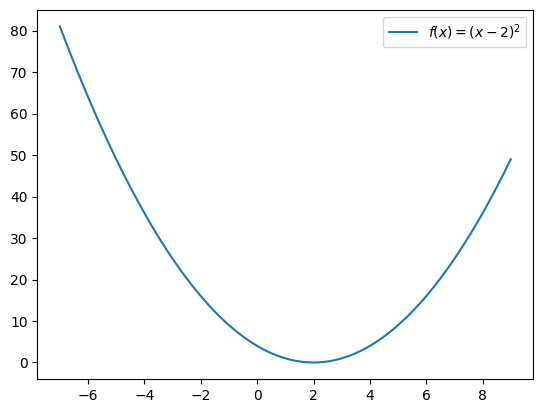

In [25]:
def f(x):
    return torch.pow((x-2.0), 2)

x_axis_vals = np.linspace(-7,9,100) 
y_axis_vals = f(torch.tensor(x_axis_vals)).numpy()

sns.lineplot(x=x_axis_vals, y=y_axis_vals, label='$f(x)=(x-2)^2$')

<Axes: >

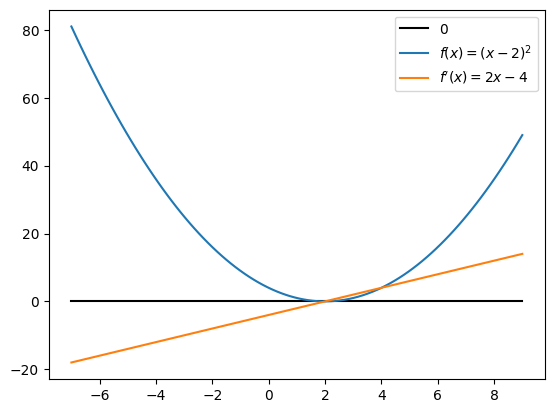

In [26]:
def fP(x): #Defining the derivative of f(x) manually
    return 2*x-4

y_axis_vals_p = fP(torch.tensor(x_axis_vals)).numpy()

#First, lets draw a black line at 0, so that we can easily tell if something is positive or negative
sns.lineplot(x=x_axis_vals, y=[0.0]*len(x_axis_vals), label="0", color='black')
sns.lineplot(x=x_axis_vals, y=y_axis_vals, label='$f(x) = (x-2)^2$')
sns.lineplot(x=x_axis_vals, y=y_axis_vals_p, label="$f'(x)=2 x - 4$")

In [27]:
x = torch.tensor([-3.5], requires_grad=True)
print(x.grad)

None


In [28]:
value = f(x)
print(value)

tensor([30.2500], grad_fn=<PowBackward0>)


In [29]:
value.backward()
print(x.grad)

tensor([-11.])


In [30]:
x = torch.tensor([-3.5], requires_grad=True)

x_cur = x.clone()
x_prev = x_cur*100 #Make the initial "previous" solution larger
epsilon = 1e-5
eta = 0.1

while torch.linalg.norm(x_cur-x_prev) > epsilon:
    x_prev = x_cur.clone() #We need to make a clone here so that x_prev and x_cur don't point to the same object
    
    #Compute our function, gradient, and update
    value = f(x)
    value.backward()
    x.data -= eta * x.grad
    x.grad.zero_() #We need to zero out the old gradient, as py-torch will not do that for us
    
    #What are we currently now?
    x_cur = x.data
    
print(x_cur)

tensor([2.0000])


In [31]:
x_param = torch.nn.Parameter(torch.tensor([-3.5]), requires_grad=True)

In [32]:
optimizer = torch.optim.SGD([x_param], lr=eta)

In [33]:
for epoch in range(60):
    optimizer.zero_grad() #x.grad.zero_()
    loss_incurred  = f(x_param)
    loss_incurred.backward()
    optimizer.step() #x.data -= eta * x.grad
print(x_param.data)

tensor([2.0000])


In [36]:
from torchvision import datasets, transforms

mnist = datasets.MNIST(
    root="mnist_data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

print(len(mnist))   # 60000

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.41MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 16.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.62MB/s]

60000


In [37]:
import torch

X = torch.stack([img.view(-1) for img, _ in mnist])  # (60000, 784)
y = torch.tensor([label for _, label in mnist])      # (60000,)

In [38]:
from torch.utils.data import Dataset

class SimpleDataset(Dataset):
        
    def __init__(self, X, y):
        super(SimpleDataset, self).__init__()
        self.X = X
        self.y = y
    
    def __getitem__(self, index):
        #This "work" could have gone in the constructor, but you should get into 
        inputs = torch.tensor(self.X[index,:], dtype=torch.float32)
        targets = torch.tensor(int(self.y[index]), dtype=torch.int64)
        return inputs, targets 

    def __len__(self):
        return self.X.shape[0]
#Now we can make a PyTorch dataset 
dataset = SimpleDataset(X, y)

In [39]:
print("Length: ", len(dataset))
example, label = dataset[0]
print("Features: ", example.shape) #Will return 784
print("Label of index 0: ", label)

Length:  60000
Features:  torch.Size([784])
Label of index 0:  tensor(5)


/var/folders/7x/tfwsytqd3yjccjl53cm75j700000gn/T/ipykernel_9694/1901271569.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(self.X[index,:], dtype=torch.float32)


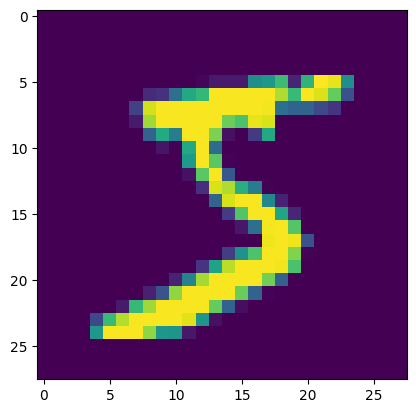

In [40]:
plt.imshow(example.reshape((28,28)))

In [41]:
train_size = int(len(dataset)*0.8)
test_size = len(dataset)-train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, (train_size, test_size))
print("{} examples for training and {} for testing".format(len(train_dataset), len(test_dataset)))

48000 examples for training and 12000 for testing
